In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
from tensorflow import keras

(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

print(train_images.shape)
print(train_labels.shape)

(60000, 28, 28)
(60000,)


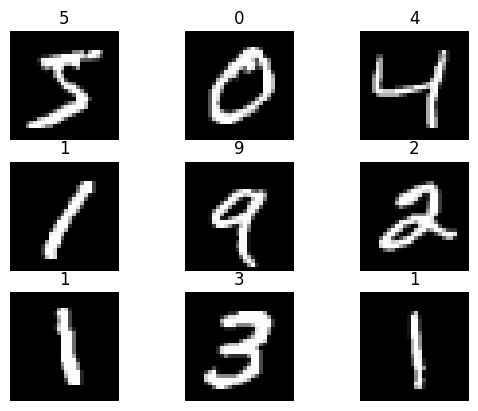

In [3]:
for i in range(9):#visualising 9 samples
    plt.subplot(3, 3, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(train_labels[i])
    plt.axis('off')
plt.show()

In [4]:
#normalizing both train and test datasets
train_images=train_images/255.0
test_images=test_images/255.0

In [5]:
#building the sequential model
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [7]:
#fit the model to compile with the correct loss
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9284 - loss: 0.2532
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9672 - loss: 0.1101
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9772 - loss: 0.0749
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9821 - loss: 0.0581
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9871 - loss: 0.0424
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9892 - loss: 0.0347
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9913 - loss: 0.0274
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9933 - loss: 0.0222
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9945 - loss: 0.0181
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9949 - loss: 0.0155


In [8]:
#training with validation split and early stopping
history=model.fit(train_images, train_labels, epochs=10, validation_split=0.2, callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',restore_best_weights=True, patience=3)])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9973 - loss: 0.0107 - val_accuracy: 0.9949 - val_loss: 0.0166
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9968 - loss: 0.0112 - val_accuracy: 0.9933 - val_loss: 0.0207
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9975 - loss: 0.0077 - val_accuracy: 0.9923 - val_loss: 0.0239
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9979 - loss: 0.0072 - val_accuracy: 0.9941 - val_loss: 0.0197


In [9]:
#plotting curves
def plot_history(history):
          fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
          ax1.plot(history.history['loss'],label='train loss')
          if 'val_loss' in history.history:
              ax1.plot(history.history['val_loss'],label='val loss')
          ax1.set_xlabel('epoch')
          ax1.set_ylabel('loss')
          ax1.legend()
          ax1.set_title('loss')

          ax2.plot(history.history['accuracy'],label='train accuracy')
          if 'val_accuracy' in history.history:
              ax2.plot(history.history['val_accuracy'],label='val accuracy')
          ax2.set_xlabel('epoch')
          ax2.set_ylabel('accuracy')
          ax2.legend()
          ax2.set_title('accuracy')
          plt.show()

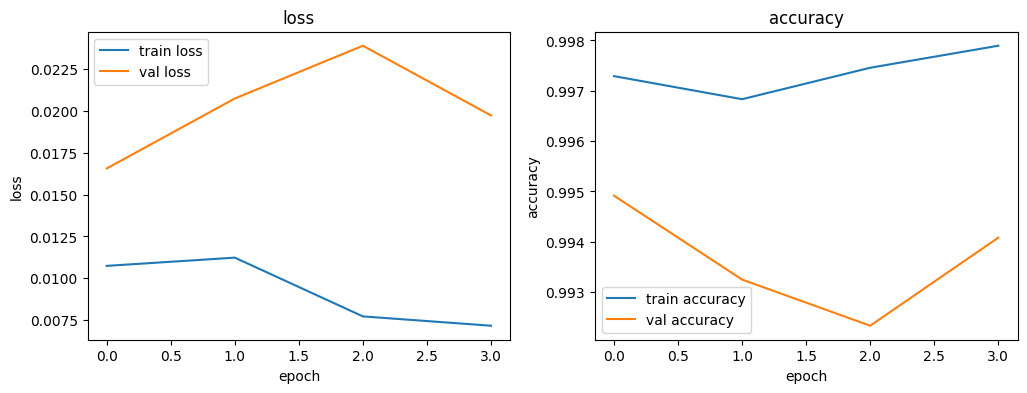

In [10]:
plot_history(history)

In [14]:
#evaluating the model
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9760 - loss: 0.0894
Test Accuracy: 0.9760000109672546
Test Loss: 0.08944792300462723


In [15]:
#getting predictions on new data
import numpy as np

predictions = model.predict(test_images)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


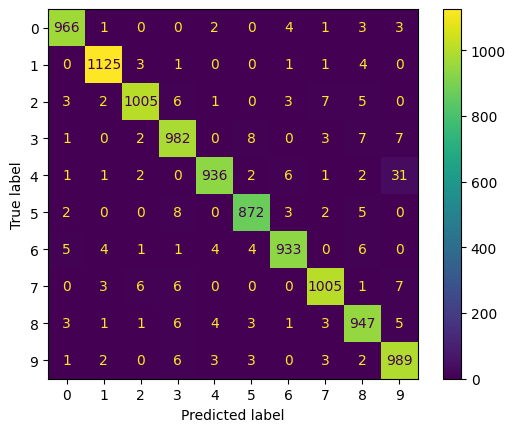

In [17]:
#plotting the confusion matrix
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, predicted_labels)

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [18]:
#save and reload the model
model.save("digits.keras")
reloaded=keras.models.load_model("digits.keras")
loss2,acc2=reloaded.evaluate(test_images,test_labels,verbose=0)
print("reloaded accuracy:",acc2)

reloaded accuracy: 0.9760000109672546
